In [14]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr

data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
abilities = pd.read_csv(os.path.join(data_dir, "Abilities.txt"), sep='\t', encoding='utf-8')
education = pd.read_csv(os.path.join(data_dir, "Education, Training, and Experience.txt"), sep='\t', encoding='utf-8')
rel = pd.read_csv(os.path.join(data_dir, "Related Occupations.txt"), sep='\t', encoding='utf-8')

In [15]:
# Skills
skills_lv = skills[skills['Scale ID'] == 'LV']
skills_im = skills[skills['Scale ID'] == 'IM']

# Abilities
abilities_lv = abilities[abilities['Scale ID'] == 'LV']
abilities_im = abilities[abilities['Scale ID'] == 'IM']

# Education: Endast RL (Required Level of Education)
# 1. Filtrera ut RL-data
edu_rl = education[education['Scale ID'] == 'RL']

# 2. Pivotera till (O*NET-SOC Code) x (RL-nivå 1–12)
edu_rl_matrix = edu_rl.pivot(index='O*NET-SOC Code', columns='Category', values='Data Value').fillna(0)

# 3. Skapa levels-array för RL 1–12
levels = np.arange(1, 13)  # [1, 2, ..., 12]

# 4. Beräkna viktat genomsnitt för varje yrke (O*NET-SOC Code)
edu_weighted_mean = (edu_rl_matrix * levels).sum(axis=1) / edu_rl_matrix.sum(axis=1)

# 5. Lägg in detta i din utbildnings-dataframe (eller bygg en om du inte har)
df_education = pd.DataFrame({'onet_code': edu_rl_matrix.index, 'edu_weighted_mean': edu_weighted_mean})

# 6. (Valfritt) Skapa kategoriindelning
def edu_category(weighted_mean):
    if weighted_mean <= 3:
        return 'Låg'
    elif weighted_mean <= 6:
        return 'Medel'
    else:
        return 'Hög'

df_education['edu_category'] = df_education['edu_weighted_mean'].apply(edu_category)

edu_rl = education[education['Scale ID'] == 'RL']

# Pivot till matriser
lv_skill_matrix = skills_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_skill_matrix = skills_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
lv_abil_matrix = abilities_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_abil_matrix = abilities_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')

# Education: Pivotera till (O*NET-SOC Code) x (RL-nivå 1–12)
edu_rl_matrix = edu_rl.pivot(index='O*NET-SOC Code', columns='Category', values='Data Value').fillna(0)

# Synka index: utgå alltid från IM-matriser
lv_skill_matrix = lv_skill_matrix.reindex(im_skill_matrix.index)
lv_abil_matrix = lv_abil_matrix.reindex(im_abil_matrix.index)

# (Valfritt) Om du vill köra PCA på domäner i exakt samma yrkesmängd:
common_codes = sorted(set(im_skill_matrix.index) & set(im_abil_matrix.index) & set(edu_rl_matrix.index))
im_skill_matrix = im_skill_matrix.loc[common_codes]
im_abil_matrix = im_abil_matrix.loc[common_codes]
edu_rl_matrix  = edu_rl_matrix.loc[common_codes]
lv_skill_matrix = lv_skill_matrix.loc[common_codes]
lv_abil_matrix = lv_abil_matrix.loc[common_codes]

edu_rl_matrix.to_csv('edu_rl_matrix_df.csv', index=True, header=True)



In [16]:
# PCA på skills (IM) – xi för ALLA domäner
pca = PCA(n_components=2)
coords = pca.fit_transform(im_skill_matrix.fillna(0).values)
xi_shared = np.arctan2(coords[:, 1], coords[:, 0]) % (2 * np.pi)

# Bygg om funktionen för att ta xi som parameter:
def build_domain_df(lv_matrix, im_matrix, occ, domain_name, xi):
    if im_matrix is None:  # Education
        data = lv_matrix.fillna(0).values
    else:
        data = im_matrix.fillna(0).values
    # xi är nu en parameter och används rakt av!
    if im_matrix is not None:
        lv_weighted = (lv_matrix * im_matrix).sum(axis=1) / im_matrix.sum(axis=1)
    else:
        levels = np.arange(1, lv_matrix.shape[1] + 1)
        lv_weighted = (lv_matrix.values * levels).sum(axis=1) / lv_matrix.sum(axis=1).values
        lv_weighted = pd.Series(lv_weighted, index=lv_matrix.index)
    chi = (lv_weighted - lv_weighted.min()) / (lv_weighted.max() - lv_weighted.min())
    occ_titles = occ.set_index('O*NET-SOC Code').reindex(lv_matrix.index)['Title']
    return pd.DataFrame({
        'onet_code': lv_matrix.index,
        'xi': xi,
        'chi': chi.values,
        'domain': domain_name,
        'title': occ_titles.values
    })

# Använd xi_shared för alla!
df_skills    = build_domain_df(lv_skill_matrix, im_skill_matrix, occ, 'Skills',    xi_shared)
df_abilities = build_domain_df(lv_abil_matrix, im_abil_matrix, occ, 'Abilities',   xi_shared)
df_education = build_domain_df(edu_rl_matrix, None,           occ, 'Education',   xi_shared)
df_plot = pd.concat([df_skills, df_abilities, df_education], ignore_index=True)


In [17]:
x = df_plot['chi'] * np.cos(df_plot['xi'])
y = df_plot['chi'] * np.sin(df_plot['xi'])
x_center = x.mean()
y_center = y.mean()
center_angle = np.arctan2(y_center, x_center) % (2 * np.pi)
df_plot['xi_rot'] = (df_plot['xi'] - center_angle) % (2 * np.pi)
df_skills['xi_rot'] = (df_skills['xi'] - center_angle) % (2 * np.pi)
df_abilities['xi_rot'] = (df_abilities['xi'] - center_angle) % (2 * np.pi)
df_education['xi_rot'] = (df_education['xi'] - center_angle) % (2 * np.pi)
print(f"Center angle: {np.degrees(center_angle):.2f} degrees")


Center angle: 157.07 degrees


8 [-0.67621415  0.96072027]
27 [ 0.63924307 -0.8731754 ]
9 [-0.95635595 -0.04852128]
25 [ 0.75986618 -0.92989407]
1 [-0.72629688 -0.217683  ]
17 [0.29655554 0.06534901]


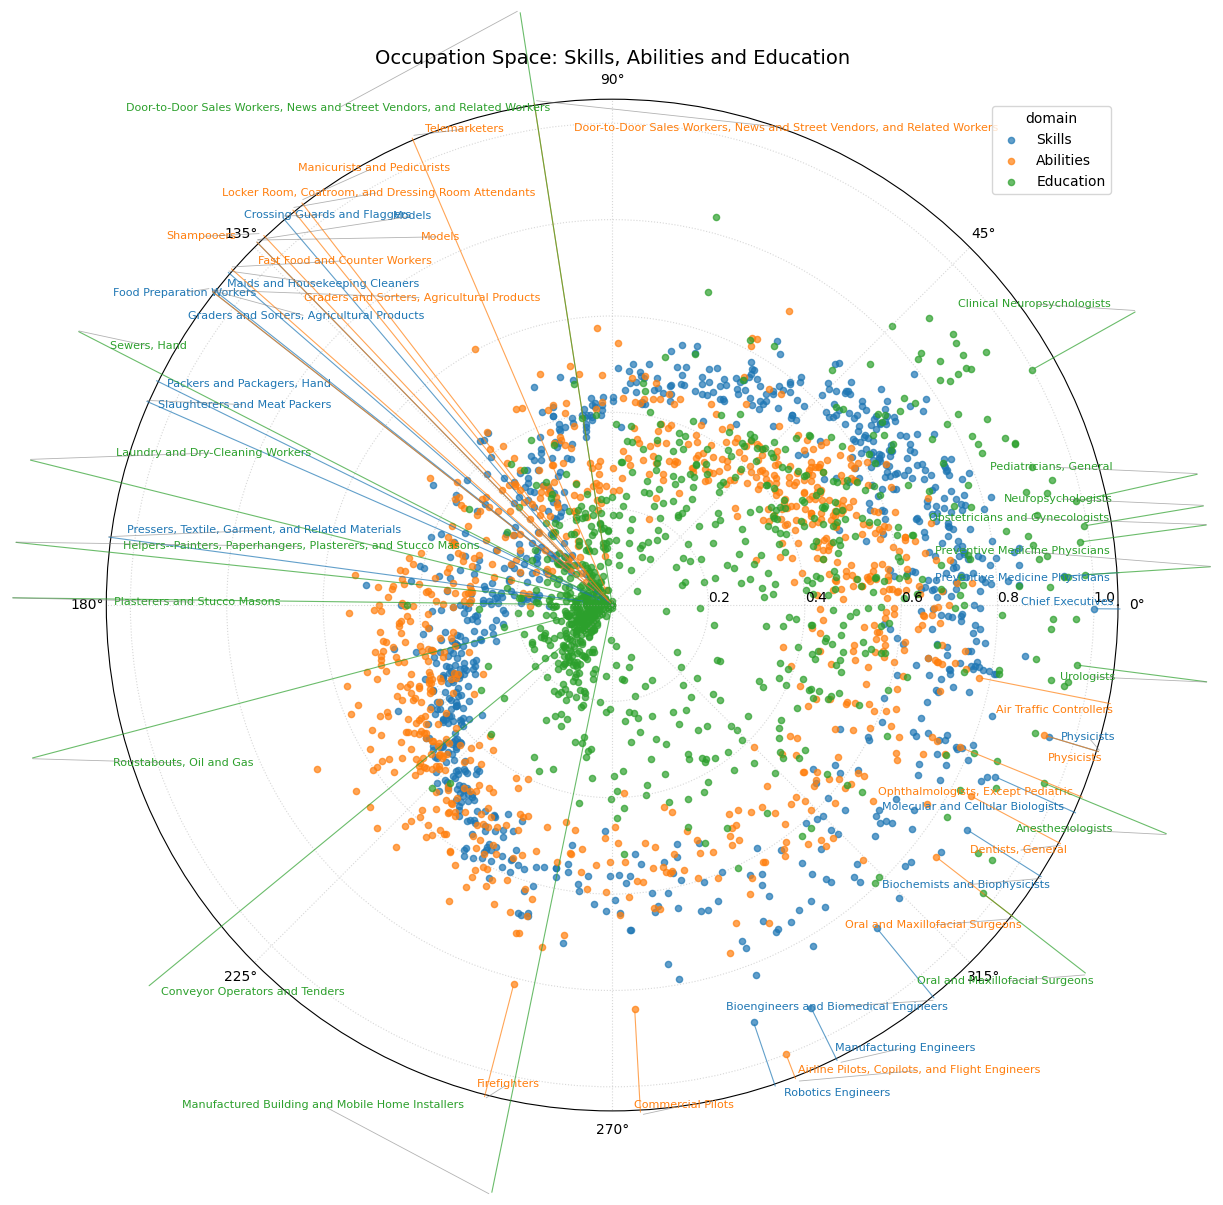

In [18]:
from adjustText import adjust_text 

def plot_occupation_space_domains(
    df,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    color_map=None,
    annotate_n=8,
    figsize=(14,12),
    title=None,
    alpha=0.7
):
    unique_domains = df[domain_col].unique()
    if color_map is None:
        colors = plt.cm.tab10.colors
        color_map = {dom: colors[i % len(colors)] for i, dom in enumerate(unique_domains)}
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})
    for dom in unique_domains:
        mask = df[domain_col] == dom
        ax.scatter(df.loc[mask, xi_col], df.loc[mask, chi_col],
                   color=color_map[dom], alpha=alpha, s=20, label=dom)
    texts = []
    for dom in unique_domains:
        mask = df[domain_col] == dom
        sub = df.loc[mask]
        idx_max = sub[chi_col].nlargest(annotate_n).index
        idx_min = sub[chi_col].nsmallest(annotate_n).index
        idxs = pd.Index(idx_max.tolist() + idx_min.tolist()).unique()
        annots = sub.loc[idxs]

        # Sätt längre radie för etiketter för just Education
        if dom == 'Education':
            chi_label_dom = 1.25  # T ex 1.25 för Education
        else:
            chi_label_dom = 1.06  # Standard för övriga

        for _, row in annots.iterrows():
            angle = row[xi_col]
            # Bygg textobjekt och spara till texts-listan:
            txt = ax.text(
                angle, chi_label_dom,
                row.get('title', row.get('onet_code', '')),
                fontsize=8,
                ha='center', va='center',
                color=color_map[dom]
            )
            # Rita pil från label till punkt
            ax.annotate('', xy=(angle, row[chi_col]), xytext=(angle, chi_label_dom),
                        textcoords='data', arrowprops=dict(arrowstyle='-', lw=0.8, color=color_map[dom], alpha=0.7))
            texts.append(txt)

    # Justera etiketterna med adjustText (försök undvika överlapp)
    adjust_text(texts, ax=ax, expand_points=(2.8, 2.8), expand_text=(1.7, 1.7),
                force_text=2.5,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.6))

    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.legend(loc='upper right', fontsize=10, title=domain_col)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('occupation_space.svg', format='svg', bbox_inches='tight')
    plt.show()
    return fig, ax

# Plot
plot_occupation_space_domains(
    df_plot,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    annotate_n=8,
    title='Occupation Space: Skills, Abilities and Education'
)
df_plot.to_csv('occupation_space_df.csv', index=False)


In [19]:
def ocs_near_correlation(df_domain, rel, domain_label):
    df_domain = df_domain.copy()
    df_domain['x'] = df_domain['chi'] * np.cos(df_domain['xi_rot'])
    df_domain['y'] = df_domain['chi'] * np.sin(df_domain['xi_rot'])
    code2xy = df_domain.set_index('onet_code')[['x', 'y']].to_dict('index')
    def occs_distance(row):
        code1 = row['O*NET-SOC Code']
        code2 = row['Related O*NET-SOC Code']
        xy1 = code2xy.get(code1)
        xy2 = code2xy.get(code2)
        if xy1 is not None and xy2 is not None:
            return np.sqrt((xy1['x'] - xy2['x'])**2 + (xy1['y'] - xy2['y'])**2)
        else:
            return np.nan
    rel[f'ocs_distance_{domain_label}'] = rel.apply(occs_distance, axis=1)
    coords = df_domain[['x', 'y']].values
    codes = df_domain['onet_code'].values
    dist_matrix = cdist(coords, coords)
    nearest_ranks = {}
    for i, code in enumerate(codes):
        dists = dist_matrix[i]
        sorted_indices = np.argsort(dists)
        sorted_codes = codes[sorted_indices]
        nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}
    rel[f'ocs_rank_{domain_label}'] = rel.apply(
        lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
        axis=1
    )
    mask = rel[f'ocs_distance_{domain_label}'].notna() & rel[f'ocs_rank_{domain_label}'].notna()
    x = rel.loc[mask, f'ocs_rank_{domain_label}']
    y = rel.loc[mask, f'ocs_distance_{domain_label}']
    spearman = spearmanr(x, y)
    pearson = pearsonr(x, y)
    print(f"\n==== {domain_label} ====")
    print('Spearman rangkorrelation:', spearman)
    print('Pearson korrelation:', pearson)
    return rel

rel = ocs_near_correlation(df_skills, rel, 'skills')
rel = ocs_near_correlation(df_abilities, rel, 'abilities')
rel = ocs_near_correlation(df_education, rel, 'education')



==== skills ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9383289361308985), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.9493754521522442), pvalue=np.float64(0.0))

==== abilities ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9393624824082977), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.950141494552124), pvalue=np.float64(0.0))

==== education ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.7071092337438558), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.7882997933615219), pvalue=np.float64(0.0))


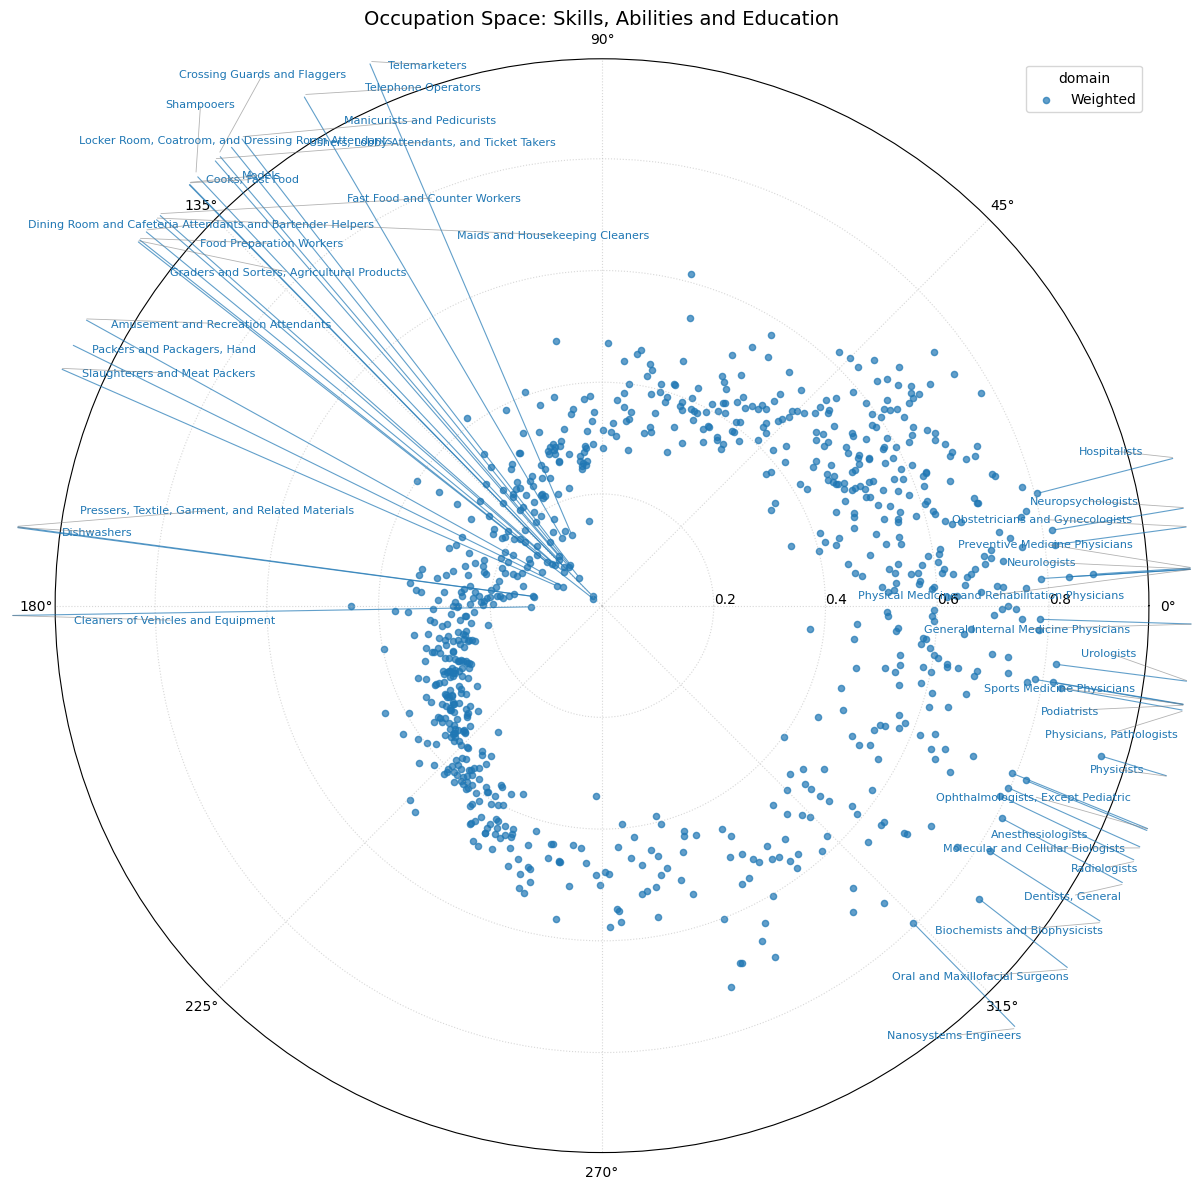

(<Figure size 1400x1200 with 1 Axes>,
 <PolarAxes: title={'center': 'Occupation Space: Skills, Abilities and Education'}>)

In [20]:
# Säkerställ gemensamt index för alla tre dataframes
common_codes = (
    set(df_skills['onet_code']) &
    set(df_abilities['onet_code']) &
    set(df_education['onet_code'])
)
common_codes = sorted(common_codes)
df_skills_c = df_skills.set_index('onet_code').loc[common_codes]
df_abilities_c = df_abilities.set_index('onet_code').loc[common_codes]
df_education_c = df_education.set_index('onet_code').loc[common_codes]

# Ta xi från skills, men medelvärde av chi
df_weighted = pd.DataFrame({
    'onet_code': common_codes,
    'title': df_skills_c['title'],
    'xi': df_skills_c['xi'],      # xi från skills-PCA
    'chi': (
        df_skills_c['chi'] * (1/3) +
        df_abilities_c['chi'] * (1/3) +
        df_education_c['chi'] * (1/3)
    ),
    'domain': 'Weighted'
})

# Lägg till eventuella andra kolumner som behövs (exempelvis xi_rot etc.)
# Rotera xi så att tyngdpunkten hamnar rätt (samma metod som tidigare)
x = df_weighted['chi'] * np.cos(df_weighted['xi'])
y = df_weighted['chi'] * np.sin(df_weighted['xi'])
x_center = x.mean()
y_center = y.mean()
center_angle = np.arctan2(y_center, x_center) % (2 * np.pi)
df_weighted['xi_rot'] = (df_weighted['xi'] - center_angle) % (2 * np.pi)

# Nu kan du plotta precis som tidigare!
plot_occupation_space_domains(
    df_weighted,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    annotate_n=20,
    title='Occupation Space: Skills, Abilities and Education'
)


I nästa cell läser vi in crosswalk-tabeller från U.S. Bureau of Labour Statistics och använder dem för att översätta O*NET till ACS som används i del Rio Chanonas transitionstabell.
 
https://www.bls.gov/emp/documentation/crosswalks.htm

Förklaring av pipeline:
Steg 1: Använder nem-onet-to-soc-crosswalk.xlsx för att gå från O*NET till SOC6.

Steg 2: Använder nem-occcode-acs-crosswalk.xlsx för att gå från SOC6 till ACS.

Slutresultat: Varje rad i din analysdataframe får en kolumn acs_occ_code som är direkt användbar för lookup i labels_df och mobilitetsmatrisen P.

In [41]:
import pandas as pd

# ---- Steg 1: O*NET → SOC6/NEM ----
nem_path_1 = "nem-onet-to-soc-crosswalk.xlsx"
nem_df = pd.read_excel(nem_path_1, skiprows=4)
nem_df['O*NET-SOC Code'] = nem_df['O*NET-SOC Code'].astype(str)
nem_df['NEM Code'] = nem_df['NEM Code'].astype(str)

# O*NET → SOC6
onet_to_soc6 = dict(zip(nem_df['O*NET-SOC Code'], nem_df['NEM Code']))
onet_to_title = dict(zip(nem_df['O*NET-SOC Code'], nem_df['National Employment Matrix Occupational Title']))

# ---- Steg 2: SOC6 → ACS ----
nem_path_2 = "nem-occcode-acs-crosswalk.xlsx"
soc_acs_df = pd.read_excel(nem_path_2, skiprows=4)  # Headers ligger på rad 5 (0-indexerat)
soc_acs_df['Matrix Occupation Code'] = soc_acs_df['Matrix Occupation Code'].astype(str)
soc_acs_df['ACS Code'] = soc_acs_df['ACS Code'].astype(str).str.lstrip('0') # Ta bort ev ledande nollor

# SOC6 → ACS
soc6_to_acs = dict(zip(soc_acs_df['Matrix Occupation Code'], soc_acs_df['ACS Code']))
soc6_to_title = dict(zip(soc_acs_df['Matrix Occupation Code'], soc_acs_df['Matrix Occupation Title']))

# ---- Skapa analysdataframe ----
df_trans_plot = df_plot.copy()
if df_trans_plot.index.name == 'onet_code':
    df_trans_plot = df_trans_plot.reset_index()

# Lägg till SOC6/NEM-kod
df_trans_plot['soc6'] = df_trans_plot['onet_code'].map(onet_to_soc6)
df_trans_plot['nem_title'] = df_trans_plot['onet_code'].map(onet_to_title)

# Lägg till ACS-kod (steg 2)
df_trans_plot['acs_occ_code'] = df_trans_plot['soc6'].map(soc6_to_acs)
df_trans_plot['acs_title'] = df_trans_plot['soc6'].map(soc6_to_title)

df_trans_plot = df_trans_plot.drop_duplicates(subset='onet_code')

# Kolla stickprov/resultat
print(df_trans_plot[['onet_code','soc6','acs_occ_code','nem_title','acs_title']].head(15))


     onet_code     soc6 acs_occ_code  \
0   11-1011.00  11-1011           10   
1   11-1011.03  11-1011           10   
2   11-1021.00  11-1021           20   
3   11-2011.00  11-2011           40   
4   11-2021.00  11-2021           51   
5   11-2022.00  11-2022           52   
6   11-3012.00  11-3012          101   
7   11-3013.00  11-3013          102   
8   11-3021.00  11-3021          110   
9   11-3031.00  11-3031          120   
10  11-3031.01  11-3031          120   
11  11-3031.03  11-3031          120   
12  11-3051.00  11-3051          140   
13  11-3051.01  11-3051          140   
14  11-3051.02  11-3051          140   

                                    nem_title  \
0                            Chief executives   
1                            Chief executives   
2             General and operations managers   
3         Advertising and promotions managers   
4                          Marketing managers   
5                              Sales managers   
6            Adm

Antal transitions hittade: 0
Exempel transitions: []
0 transitions med O*NET-koder redo för plottning.


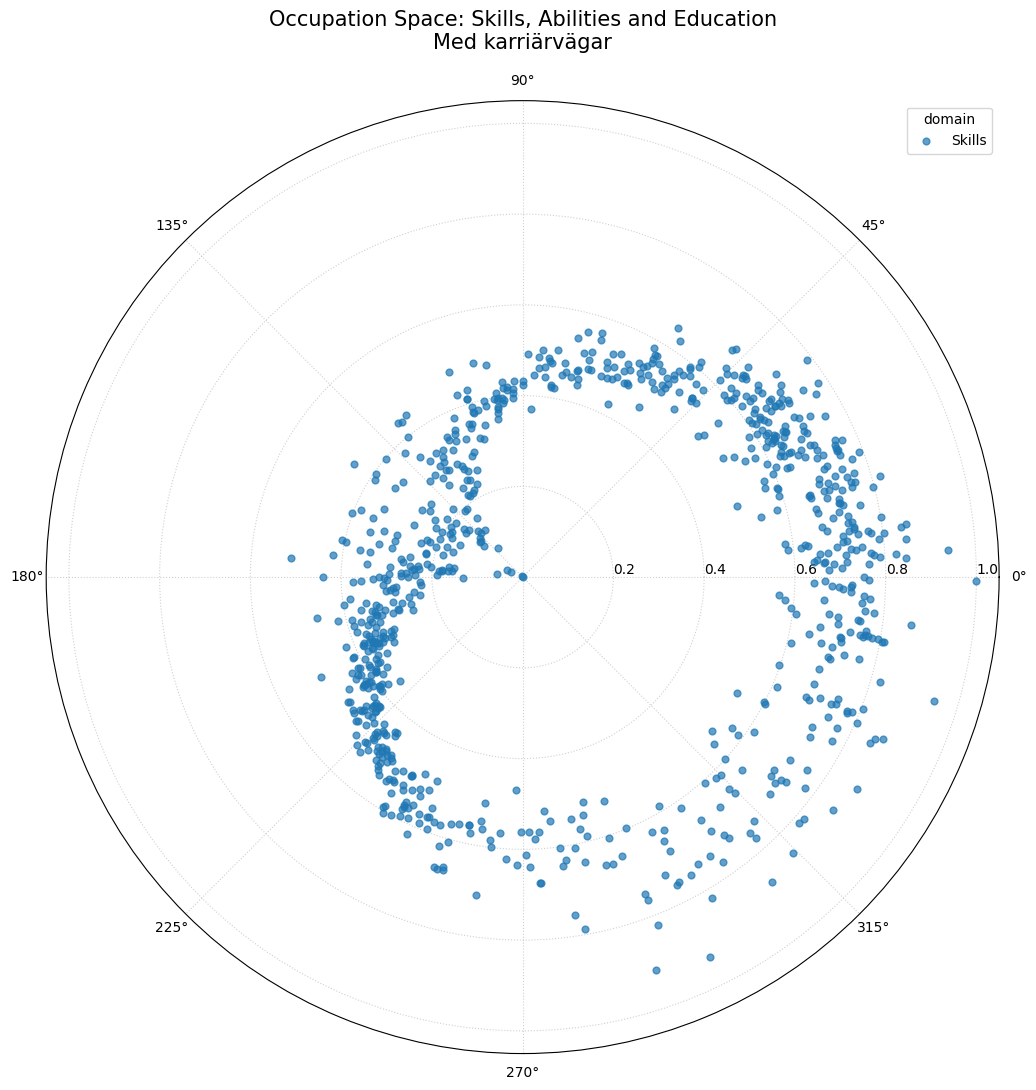

In [38]:


# ==== 4. Skapa transitions via ACS och labels ====

threshold = 0.001
top_transitions = []

for occ in df_trans_plot['acs_occ_code'].dropna().astype(str):
    label_source = acs_to_label.get(occ)
    if label_source is None or label_source not in P.index:
        continue

    probs = P.loc[label_source].drop(index=label_source)
    top_targets = probs[probs > threshold].nlargest(3)

    for label_target, weight in top_targets.items():
        target_acs = label_to_acs.get(label_target)
        if target_acs is None:
            continue
        top_transitions.append((occ, target_acs, weight))

print(f"Antal transitions hittade: {len(top_transitions)}")
print("Exempel transitions:", top_transitions[:5])

# ==== 5. Mappa transitions från ACS → O*NET-koder ====

acs_to_onet = dict(zip(df_trans_plot['acs_occ_code'].dropna().astype(str), df_trans_plot['onet_code']))

top_transitions_onet = []
for src_acs, tgt_acs, w in top_transitions:
    src_onet = acs_to_onet.get(src_acs)
    tgt_onet = acs_to_onet.get(tgt_acs)
    if (src_onet in df_trans_plot['onet_code'].values) and (tgt_onet in df_trans_plot['onet_code'].values):
        top_transitions_onet.append((src_onet, tgt_onet, w))

print(f"{len(top_transitions_onet)} transitions med O*NET-koder redo för plottning.")

# ==== 6. Visualisera transitions i Occupation Space ====

def plot_occupation_space_with_transitions(
    df,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    color_map=None,
    annotate_n=8,
    top_transitions=None,
    transition_norm=None,
    transition_cmap=None,
    threshold=0.001,
    figsize=(13,11),
    title=None,
    alpha=0.7
):
    unique_domains = df[domain_col].unique()
    if color_map is None:
        colors = plt.cm.tab10.colors
        color_map = {dom: colors[i % len(colors)] for i, dom in enumerate(unique_domains)}

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})

    for dom in unique_domains:
        mask = df[domain_col] == dom
        ax.scatter(df.loc[mask, xi_col], df.loc[mask, chi_col],
                   color=color_map[dom], alpha=alpha, s=24, label=dom, zorder=10)

    if top_transitions:
        weights = [w for _,_,w in top_transitions]
        transition_norm = mcolors.Normalize(vmin=threshold, vmax=np.percentile(weights, 95))
        transition_cmap = cm.get_cmap("viridis")

        for source, target, weight in top_transitions:
            angle1 = float(df.loc[df['onet_code']==source, xi_col])
            r1     = float(df.loc[df['onet_code']==source, chi_col])
            angle2 = float(df.loc[df['onet_code']==target, xi_col])
            r2     = float(df.loc[df['onet_code']==target, chi_col])

            norm_value = min(transition_norm(weight), 1.0)
            color = transition_cmap(norm_value)
            linewidth = 0.7 + 3.0 * norm_value
            alpha_line = min(0.07 + 0.93 * (norm_value ** 2), 0.92)
            ax.plot([angle1, angle2], [r1, r2], color=color, alpha=alpha_line, linewidth=linewidth, zorder=1)

    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.legend(loc='upper right', fontsize=10, title=domain_col)

    if title:
        ax.set_title(title, fontsize=15, pad=18)

    plt.tight_layout()
    plt.show()
    return fig, ax

# === Slutlig plottning ===
fig, ax = plot_occupation_space_with_transitions(
    df_trans_plot,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    annotate_n=8,
    top_transitions=top_transitions_onet,
    title='Occupation Space: Skills, Abilities and Education\nMed karriärvägar'
)


In [33]:
import pandas as pd

# Antag att du redan har:
# df_trans_plot (eller motsvarande DataFrame med kolumner: onet_code, acs_occ_code, title, xi_rot, chi, ...)
# labels_df (med 'acs_occ_code' och 'label')
# P (transition-matris, indexerad med labels)

# Skapa mappningar (om de inte redan finns)
acs_to_label = dict(zip(labels_df['acs_occ_code'].astype(str), labels_df['label']))
label_to_acs = dict(zip(labels_df['label'], labels_df['acs_occ_code'].astype(str)))

# Välj sektor i OCS: exempel 135–235 grader
angle_min = 135 * np.pi / 180
angle_max = 235 * np.pi / 180

mask_sector = (df_trans_plot['xi_rot'] >= angle_min) & (df_trans_plot['xi_rot'] <= angle_max)
yrken_sektor = df_trans_plot.loc[mask_sector].copy()

# Analysera varje yrke och spara resultatet i listor
records = []
for i, row in yrken_sektor.iterrows():
    onet = row['onet_code']
    acs = str(row['acs_occ_code'])
    title = row['title']
    label = acs_to_label.get(acs)
    finns_i_labels = "JA" if label is not None else "NEJ"
    finns_i_P = "JA" if (label in P.index) else "NEJ"
    records.append({
        "onet_code": onet,
        "acs_occ_code": acs,
        "title": title,
        "xi_rot": row['xi_rot'],
        "chi": row['chi'],
        "label": label if label else "",
        "finns_i_labels_df": finns_i_labels,
        "finns_i_P": finns_i_P
    })

df_out = pd.DataFrame.from_records(records)

# Spara ALLT till CSV
df_out.to_csv("yrken_i_sektor_OCS.csv", index=False, encoding="utf-8")

# Skriv även ut som text, med alla detaljer
with open("yrken_i_sektor_OCS.txt", "w", encoding="utf-8") as f:
    for _, r in df_out.iterrows():
        msg = (
            f"{r['onet_code']} (ACS: {r['acs_occ_code']}) — {r['title']}\n"
            f"  xi_rot: {r['xi_rot']:.3f}, chi: {r['chi']:.3f}\n"
            f"  label: {r['label']} | i labels_df: {r['finns_i_labels_df']} | i P.index: {r['finns_i_P']}\n"
        )
        f.write(msg + "\n")

print("KLART! Alla yrken i vald sektor sparade som:\n - yrken_i_sektor_OCS.csv\n - yrken_i_sektor_OCS.txt")


KLART! Alla yrken i vald sektor sparade som:
 - yrken_i_sektor_OCS.csv
 - yrken_i_sektor_OCS.txt
